In [ ]:
# Cell 1: Imports
import os
import cv2
import matplotlib.pyplot as plt
import random

In [ ]:
# Cell 2: Load Sample Images (BEFORE PREPROCESSING)
DATA_DIR = r"C:\Users\anind\OneDrive\Desktop\DL_Proj_Face_Emotion\data\dataset"

In [ ]:
# Cell 3: Total Number of Images

total_images = 0

for label in os.listdir(DATA_DIR):
    label_path = os.path.join(DATA_DIR, label)
    if os.path.isdir(label_path):
        total_images += len(os.listdir(label_path))

print("Total Images in Dataset:", total_images)

Total Images in Dataset: 22839


In [ ]:
# Cell 4: Total Classes + Class Names

class_names = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]

print("Total Classes:", len(class_names))
print("Class Names:")
for cls in class_names:
    print("-", cls)

Total Classes: 9
Class Names:
- Anger
- Content
- Disgust
- Fear
- Happy
- Neutral
- Sad
- SillyFace
- Surprise


In [ ]:
# Cell 5: Class-wise Image Count

class_counts = {}

for cls in class_names:
    cls_path = os.path.join(DATA_DIR, cls)
    count = len(os.listdir(cls_path))
    class_counts[cls] = count

print("Class-wise Image Distribution:\n")

for cls, count in class_counts.items():
    print(f"{cls}: {count}")

Class-wise Image Distribution:

Anger: 2310
Content: 772
Disgust: 788
Fear: 906
Happy: 4929
Neutral: 5016
Sad: 4771
SillyFace: 1116
Surprise: 2231


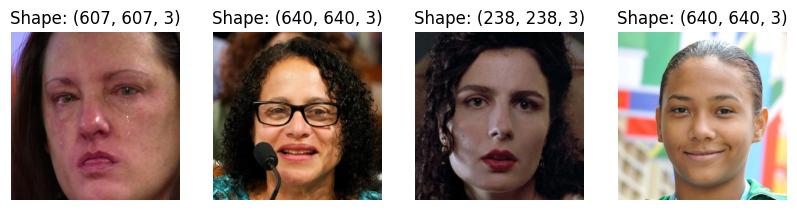

In [ ]:
def show_samples(data_dir, num=4):
    samples = []
    labels = os.listdir(data_dir)

    for label in labels:
        imgs = os.listdir(os.path.join(data_dir, label))
        for img in imgs[:1]:
            samples.append(os.path.join(data_dir, label, img))

    random.shuffle(samples)
    samples = samples[:num]

    plt.figure(figsize=(10,5))
    for i, path in enumerate(samples):
        img = cv2.imread(path)
        plt.subplot(1, num, i+1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Shape: {img.shape}")
        plt.axis("off")
    plt.show()

show_samples(DATA_DIR)

In [ ]:
# Cell 3: Face Detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 
                                     "haarcascade_frontalface_default.xml")

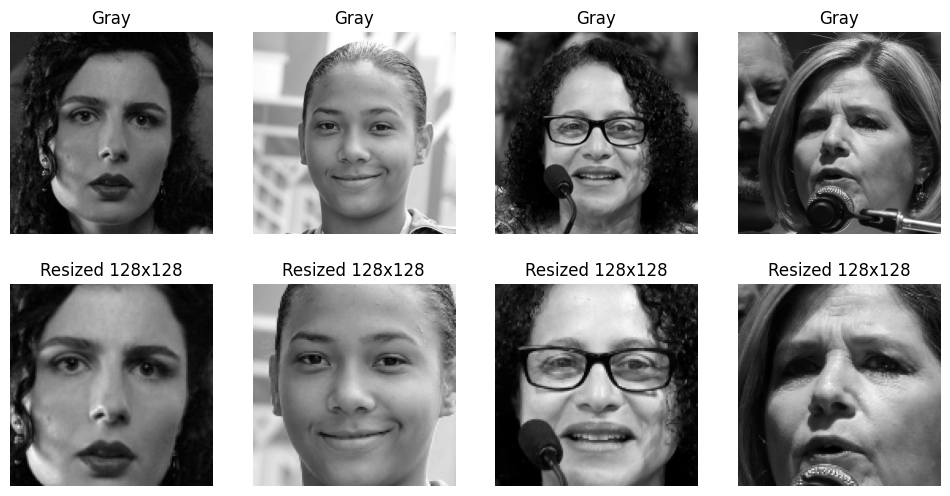

In [ ]:
# Cell 4: Resize to 128x128

def process_and_show(data_dir, num=4):
    samples = []

    for label in os.listdir(data_dir):
        imgs = os.listdir(os.path.join(data_dir, label))
        for img in imgs[:1]:
            samples.append((label, os.path.join(data_dir, label, img)))

    random.shuffle(samples)
    samples = samples[:num]

    plt.figure(figsize=(12,6))

    for i, (label, path) in enumerate(samples):
        img = cv2.imread(path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        for (x,y,w,h) in faces:
            face = gray[y:y+h, x:x+w]
            resized = cv2.resize(face, (128,128))  # changed here

            plt.subplot(2, num, i+1)
            plt.imshow(gray, cmap='gray')
            plt.title("Gray")
            plt.axis("off")

            plt.subplot(2, num, i+1+num)
            plt.imshow(resized, cmap='gray')
            plt.title("Resized 128x128")
            plt.axis("off")

            break

    plt.show()

process_and_show(DATA_DIR)